In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
from jaxtyping import Float

import dismech_jax as djx

from util import *
from helpers import *
from animate import animate

jax.config.update("jax_enable_x64", True)

In [2]:
from Energy_NN_architectures import *

K_init = jnp.array([0.2, 0.02])

# train_data = "../data/combined_output_new_train.npz"
# valid_data = "../data/combined_output_new_test.npz"

# train_file = "training_data.npz"
# valid_file = "validation_data.npz"
# # convert to direct-BC format
# convert_linear_bc_to_direct_bc(train_data, train_file, lambdas=None)
# convert_linear_bc_to_direct_bc(valid_data, valid_file, lambdas=None)


# train_file = "../experiment_data/combined_train_dataset.npz"
# valid_file = "../experiment_data/combined_test_dataset.npz"

train_file = "../experiment_data/n5_combined_train_dataset.npz"
valid_file = "../experiment_data/n5_combined_test_dataset.npz"


In [3]:
from properties import Properties

properties = Properties(
    length = 0.2,
    r0 = 0.005,
    axs = None,
    jxs = None,
    ixs1 = None,
    ixs2 = None,
    density = 800.0,
    E = 1e6,
    N = 5,
    # start = jax.numpy.array([0, 0, 0]),
    # end = jax.numpy.array([0.266166, 0., 0.01240256]),
    mass = 0.3
)

params = ModelParams(
    der_K=K_init,
    key=jax.random.PRNGKey(0),
    hidden=(10,),
    which_case="ICNN",
    corr_factor=0.01,
    input_mode="raw",
    zero_reference=True,
    activation="tanh"
)

model_cls = DiagonalPlusEnergyNN

final_model, train_history, valid_history = train_model(properties=properties, model_cls=model_cls, params=params, train_file=train_file, valid_file=valid_file, n_epochs=500, lr=5e-2)

Epoch 000 | Train: 4.322e-03 | Valid: 2.669e-03
Epoch 100 | Train: 1.890e-03 | Valid: 1.503e-03
Epoch 200 | Train: 1.869e-03 | Valid: 1.456e-03
Epoch 300 | Train: 1.861e-03 | Valid: 1.467e-03
Epoch 400 | Train: 1.857e-03 | Valid: 1.852e-03


500


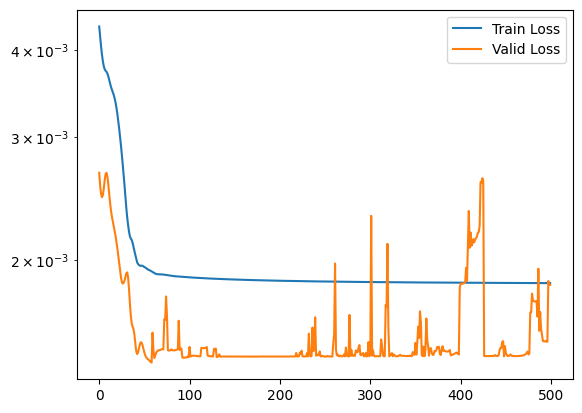

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

print(len(train_history))

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
base, aux = get_slinky(properties)
valid = Dataset.load(valid_file)
pred = predict(final_model, base, aux, valid.idx_b, valid.xb, valid.lambdas)

In [6]:
print(pred.shape)

(4, 54, 19)


In [7]:
animate(pred[1], n_nodes=properties.N)


In [8]:
animate(valid.qs[1])

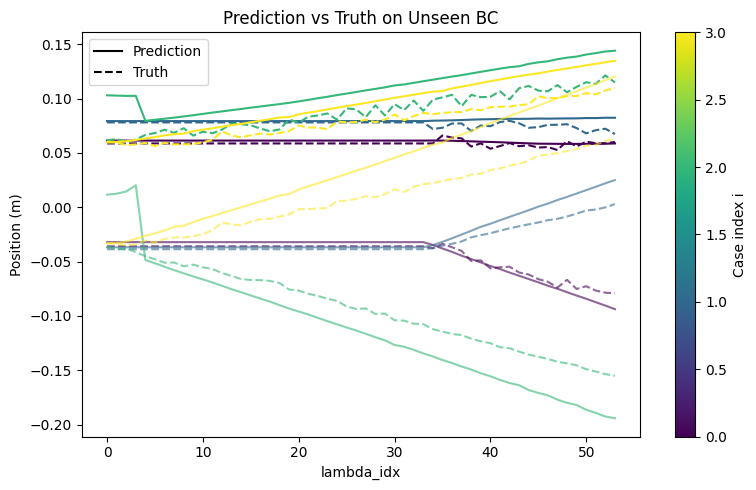

In [9]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import jax.numpy as jnp

n_cases = pred.shape[0]
colors = cm.viridis(jnp.linspace(0, 1, n_cases))

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(n_cases):
    c = colors[i]

    # X
    ax.plot(pred[i, :, 4], color=c, linestyle='-')
    ax.plot(valid.qs[i, :, 4], color=c, linestyle='--')

    # Z
    ax.plot(pred[i, :, 6], color=c, linestyle='-', alpha=0.6)
    ax.plot(valid.qs[i, :, 6], color=c, linestyle='--', alpha=0.6)

pred_line = mlines.Line2D([], [], color='black', linestyle='-', label='Prediction')
truth_line = mlines.Line2D([], [], color='black', linestyle='--', label='Truth')
ax.legend(handles=[pred_line, truth_line])

sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=0, vmax=n_cases - 1))
sm.set_array([])  # helps matplotlib know this is a valid mappable
fig.colorbar(sm, ax=ax, label='Case index i')

ax.set_title("Prediction vs Truth on Unseen BC")
ax.set_xlabel("lambda_idx")
ax.set_ylabel("Position (m)")
fig.tight_layout()
plt.show()